In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from dadk.BinPol import *

#### Input dataset

In [2]:
### Ecosystem of batteries

In [3]:
req_final_energy_perc = 30
initial_energy_perc = 50

df_bat = pd.DataFrame()
df_bat['Type'] = ['EV', 'C&I', 'Residential']
df_bat['Quantity'] = [2, 1, 2]
df_bat['Capacity(kWh)'] = [200, 2000, 20]
df_bat['Charging_rate(kW)'] = [20, 200, 10]
df_bat['Dicharging_rate(kW)'] = [10, 100, 5]
df_bat['C_eff(%)'] = [90, 90, 90]
df_bat['D_eff(%)'] = [90, 90, 90]
df_bat['E_initial(kWh)'] = (df_bat['Capacity(kWh)']*initial_energy_perc/100).astype(int) #### It can be randomized
df_bat['E_required(kWh)'] = (df_bat['Capacity(kWh)']*req_final_energy_perc/100).astype(int) #### It can be randomized
df_bat

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,2,200,20,10,90,90,100,60
1,C&I,1,2000,200,100,90,90,1000,600
2,Residential,2,20,10,5,90,90,10,6


In [4]:
# Repeat each row by its Quantity
df_expanded = df_bat.loc[df_bat.index.repeat(df_bat['Quantity'])].reset_index(drop=True)

# Set Quantity to 1 for each battery
df_expanded['Quantity'] = 1

df_expanded

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,1,200,20,10,90,90,100,60
1,EV,1,200,20,10,90,90,100,60
2,C&I,1,2000,200,100,90,90,1000,600
3,Residential,1,20,10,5,90,90,10,6
4,Residential,1,20,10,5,90,90,10,6


In [5]:
### Normalize capacities

In [6]:
### Tranformer maximum capacity

K = 10000 ### expressed in kW

In [7]:
### Trading window

T = 8 ### expressed in hours

In [8]:
### Number of batteries

num_batteries = df_bat['Quantity'].sum()

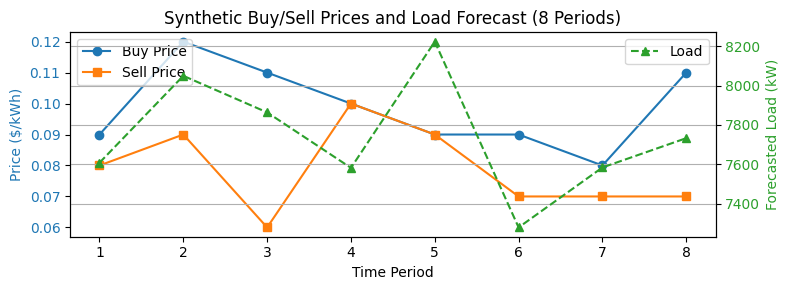

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Number of time periods
T = T

# Generate synthetic data
buy_prices = np.random.uniform(80/1000, 120/1000, T).round(2)
sell_prices = np.random.uniform(60/1000, 100/1000, T).round(2)
load = np.random.uniform(7000, 9000, T).round()

# Create DataFrame
df = pd.DataFrame({
    "Time Period": np.arange(1, T + 1),
    "Buy Price ($/kWh)": buy_prices,
    "Sell Price ($/kWh)": sell_prices,
    "Forecasted Load (kW)": load
})

# Plot
fig, ax1 = plt.subplots(figsize=(8, 3))
ax1.set_title("Synthetic Buy/Sell Prices and Load Forecast (8 Periods)")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Price ($/kWh)", color='tab:blue')
ax1.plot(df["Time Period"], df["Buy Price ($/kWh)"], label="Buy Price", marker='o', color='tab:blue')
ax1.plot(df["Time Period"], df["Sell Price ($/kWh)"], label="Sell Price", marker='s', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Second y-axis for load
ax2 = ax1.twinx()
ax2.set_ylabel("Forecasted Load (kW)", color='tab:green')
ax2.plot(df["Time Period"], df["Forecasted Load (kW)"], label="Load", marker='^', linestyle='--', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.legend(loc="upper right")

plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# Create desired output DataFrame
output_df = pd.DataFrame({
    "timestamp": df["Time Period"],
    "excess_capacity(kW)": (K - df["Forecasted Load (kW)"]).astype(int)
})
output_df

,timestamp,excess_capacity(kW)
0,1,2392
1,2,1950
2,3,2136
3,4,2418
4,5,1776
5,6,2721
6,7,2416
7,8,2267


# Create problem variables

In [11]:
my_bit_charging_indicator_array = BitArrayShape(name='charging_array', shape=(df_bat['Quantity'].sum(),T), axis_names=['battery','interval'])
my_bit_discharging_indicator_array = BitArrayShape(name='discharging_array', shape=(df_bat['Quantity'].sum(),T), axis_names=['battery','interval'])

## Slack Variables

##### 1) Slack for consecutive charging and discharging: No consecutive charging or discharging up to 3 periods

In [12]:
slack_consec_charg_list = []

for i in range(num_batteries):
    slack_var_name = f"slack_consec_charge_battery_{i}"
    slack_consec_charg_list.append(VarSlack(name=slack_var_name,start=0,step=1,stop=3,slack_type=SlackType.binary))


slack_consec_discharg_list = []

for i in range(num_batteries):
    slack_var_name = f"slack_consec_discharge_battery_{i}"
    slack_consec_discharg_list.append(VarSlack(name=slack_var_name,start=0,step=1,stop=3,slack_type=SlackType.binary))

In [13]:
my_varshapeset = VarShapeSet(my_bit_charging_indicator_array,
                             my_bit_discharging_indicator_array,
                             *slack_consec_charg_list,
                             *slack_consec_discharg_list)

## Constraints

##### 1) Exclusivity (HARD): No charging and discharging at the same time

In [14]:
H_exclusive = BinPol(my_varshapeset)

for i in range(num_batteries):
    for t in range(T):
        H_exclusive.add_term(1, (("charging_array", i, t), ("discharging_array", i, t)))

# Now normalization works
H_exclusive_normalized = H_exclusive * (1 / (num_batteries * T))

##### 2) Consecutive charging/discharging (SOFT): No consecutive charging and discharging periods

In [15]:
H_consec_charging = BinPol(my_varshapeset)

for i in range(num_batteries):
    
    H_consec_sub_char = BinPol(my_varshapeset)
    
    for t in range(T - 3):
        
        H_consec_sub_char.add_term(1, (("charging_array", i, t),))
        H_consec_sub_char.add_term(1, (("charging_array", i, t+1),))
        H_consec_sub_char.add_term(1, (("charging_array", i, t+2),))

    # Build the quadratic penalty
    H_consec_charging += ((H_consec_sub_char - 2).add_variable('slack_consec_charge_battery_'+str(i))) ** 2

H_consec_charging *= 1 / (num_batteries * (T - 2))

In [16]:
H_consec_discharging = BinPol(my_varshapeset)

for i in range(num_batteries):
    
    H_consec_sub_dischar = BinPol(my_varshapeset)
    
    for t in range(T - 3):
        
        H_consec_sub_dischar.add_term(1, (("discharging_array", i, t),))
        H_consec_sub_dischar.add_term(1, (("discharging_array", i, t+1),))
        H_consec_sub_dischar.add_term(1, (("discharging_array", i, t+2),))

    # Build the quadratic penalty
    H_consec_discharging += ((H_consec_sub_dischar - 2).add_variable('slack_consec_discharge_battery_'+str(i))) ** 2

H_consec_discharging *= 1 / (num_batteries * (T - 2))

##### 3) Transformer capacity limit (HARD)

In [17]:
H_transformer_capacity = BinPol(my_varshapeset)

scale_factor = float(output_df['excess_capacity(kW)'].max())

for t in range(T):
    H_sub = BinPol(my_varshapeset)
    
    for i in range(num_batteries):
        eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
        eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
        charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
        discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

        H_sub.add_term(eff_c * charge_rate, (("charging_array", i, t),))
        H_sub.add_term(-1/eff_d * discharge_rate, (("discharging_array", i, t),))

    Kt = float(output_df.iloc[t]['excess_capacity(kW)'])  #### Kt = Lt - K

    H_transformer_capacity += (H_sub - Kt) ** 2

# Normalize after summation
H_transformer_capacity_normalized = H_transformer_capacity * (1 / scale_factor**2)

## Objective(s)

##### 1) Maximize profit versus loss

In [18]:
# Estimate max value
max_main = 0.0
for i in range(num_batteries):
    eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
    eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
    charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
    discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']
    for t in range(T):
        max_main += max(abs(eff_c * charge_rate), abs(eff_d * discharge_rate))

# Build and normalize H_main
H_main = BinPol(my_varshapeset)
for i in range(num_batteries):
    eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
    eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
    charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
    discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']
    for t in range(T):
        buy_price = df.iloc[t]['Buy Price ($/kWh)']
        sell_price = df.iloc[t]['Sell Price ($/kWh)']
        H_main.add_term(eff_c * charge_rate * buy_price, (("charging_array", i, t),))
        H_main.add_term(-1/eff_d * discharge_rate * sell_price, (("discharging_array", i, t),))

# Normalize and scale
H_main_normalized = (H_main / max_main)

##### 2) Maximize user satisfaction

In [19]:
H_energy_tracking = BinPol(my_varshapeset)


for i in range(num_batteries):
    
    E_o_i = df_expanded.iloc[i]['E_initial(kWh)']
    E_r_i = df_expanded.iloc[i]['E_required(kWh)']
    eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
    eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
    charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
    discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']
    
    H_energy_i_t = BinPol(my_varshapeset)

    E_diff = float(E_o_i - E_r_i)
    
    for t in range(T):
        
        # Add cumulative sum from v=0 to t
        for v in range(t + 1):
            
            H_energy_i_t.add_term(eff_c * charge_rate, (("charging_array", i, v),))
            H_energy_i_t.add_term(-1/eff_d * discharge_rate, (("discharging_array", i, v),))

        # Square the deviation
    H_energy_tracking += (H_energy_i_t + E_diff) ** 2


E_initial = list(df_expanded['E_initial(kWh)'])
E_required = list(df_expanded['E_required(kWh)'])

scale_E = max(abs(np.array(E_initial) - np.array(E_required))) + 1  # Add 1 to avoid div/0
H_energy_tracking_normalized = H_energy_tracking * (1 / (scale_E**2 * T * num_batteries))

##### 3) Minimize electricity load

In [20]:
# H_net_load = BinPol(my_varshapeset)  # Objective: Minimize net transformer load (after DER actions)

# scale_net_load = df['Forecasted Load (kW)'].max() + 1  # To normalize

# for t in range(T):
    
#     H_t = BinPol(my_varshapeset)

#     L_t = float(df.iloc[t]['Forecasted Load (kW)'])  # Forecasted grid load

#     for i in range(num_batteries):
        
#         eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
#         eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
#         charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
#         discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

#         # Add charge to load
#         H_t.add_term(eff_c * charge_rate, (("charging_array", i, t),))

#         # Subtract discharge from load
#         H_t.add_term(-discharge_rate / eff_d, (("discharging_array", i, t),))

#     # Penalize total load at time t
#     H_net_load += ((H_t + L_t) * (1 / scale_net_load)) ** 2

In [21]:
H_net_load_variance = BinPol(my_varshapeset)
L_avg = BinPol(my_varshapeset)

# 1. Build symbolic average load
for t in range(T):
    L_t = float(df.iloc[t]['Forecasted Load (kW)'])
    L_avg += L_t / T

    for i in range(num_batteries):
        eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
        eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
        charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
        discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

        L_avg.add_term(eff_c * charge_rate / T, (("charging_array", i, t),))
        L_avg.add_term(-discharge_rate / (eff_d * T), (("discharging_array", i, t),))

# 2. Penalize deviation from average
gamma = df['Forecasted Load (kW)'].max() + 1

for t in range(T):
    H_t = BinPol(my_varshapeset)
    L_t = float(df.iloc[t]['Forecasted Load (kW)'])
    
    H_t += L_t
    for i in range(num_batteries):
        eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
        eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
        charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
        discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

        H_t.add_term(eff_c * charge_rate, (("charging_array", i, t),))
        H_t.add_term(-discharge_rate / eff_d, (("discharging_array", i, t),))

    H_net_load_variance += ((H_t - L_avg) * (1 / gamma)) ** 2

## Executing

In [22]:
#Constuimos la función de coste con el término principal y todas las constraints:

lambda_main1 = 100
lambda_main2 = 200
lambda_main3 = 200
lambda_exclusivity = 10
lambda_consec_char = 1
lambda_consec_dischar = 1
lambda_transf = 5

cost_function = (lambda_main1*H_main_normalized +
                lambda_main2*H_energy_tracking_normalized +
                lambda_main3*H_net_load_variance +
                lambda_exclusivity*H_exclusive_normalized +
                lambda_consec_char*H_consec_charging +
                lambda_consec_dischar*H_consec_discharging +
                lambda_transf*H_transformer_capacity_normalized)

In [23]:
from dadk.QUBOSolverCPU import *

start_time = time.time()

solver = QUBOSolverCPU(
number_iterations=500000,
number_runs=50,
scaling_bit_precision=32,
auto_tuning=AutoTuning.AUTO_SCALING_AND_SAMPLING)

solution_list = solver.minimize(cost_function)

solution = solution_list.get_minimum_energy_solution()

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Elapsed time: {elapsed_time:.4f} seconds")


********************************************************************************
  temperature_start:                       1.01500728e+00
  temperature_end:                         1.15178142e-01
  offset_increase_rate:                    3.14746453e-01
  duration:                                0.038 sec
********************************************************************************

  max_abs_coefficient:                    112.945

********************************************************************************
Effective values (including scaling factor)
  scaling_factor:                           1.90117160e+07
  temperature_start:                        1.92970301e+07
  temperature_end:                          2.18973412e+06
  offset_increase_rate:                     5.98387018e+06
  duration:                                 0.010 sec
********************************************************************************

Elapsed time: 203.5288 seconds


In [24]:
my_bit_charging_array = solution.extract_bit_array("charging_array")
my_bit_discharging_array = solution.extract_bit_array("discharging_array")

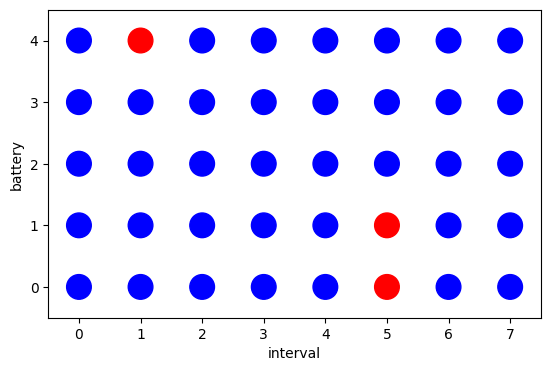

In [25]:
my_bit_charging_array.draw(order=[1,0])

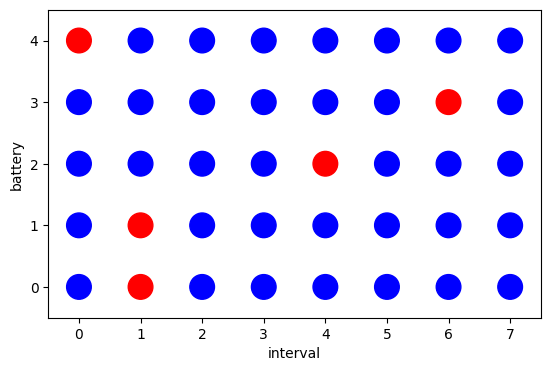

In [26]:
my_bit_discharging_array.draw(order=[1,0])

In [27]:
discharging_array = my_bit_discharging_array.data
discharging_array[discharging_array == 1] = -1

array([[ 0, -1,  0,  0,  0,  0,  0,  0],
       [ 0, -1,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, -1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, -1,  0],
       [-1,  0,  0,  0,  0,  0,  0,  0]], dtype=int8)

In [28]:
charging_array = my_bit_charging_array.data

array([[0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0]], dtype=int8)

In [29]:
array1 = discharging_array
array2 = charging_array

# Create mask where condition is true: -1 in array1 and 1 in array2
mask_conflict = (array1 == -1) & (array2 == 1)

# Start by copying array1
result = array1.copy()

# Set conflict positions to 0
result[mask_conflict] = 0

# Where array1 is 0, take value from array2
mask_array1_zero = (array1 == 0)
result[mask_array1_zero] = array2[mask_array1_zero]

array([[ 0, -1,  0,  0,  0,  1,  0,  0],
       [ 0, -1,  0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0, -1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, -1,  0],
       [-1,  1,  0,  0,  0,  0,  0,  0]], dtype=int8)

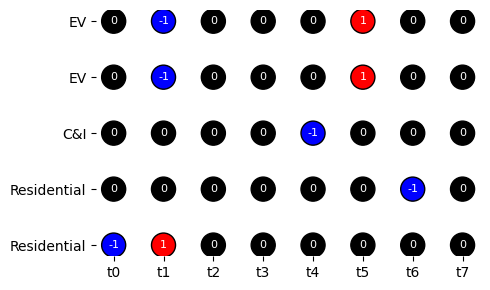

In [30]:
# Labels
row_labels = list(df_expanded['Type'])
col_labels = ['t' + str(t) for t in range(T)]

# Create figure
fig, ax = plt.subplots(figsize=(5, 3))

# Get coordinates for each value
rows, cols = np.indices(result.shape)

# Flatten for plotting
x = cols.flatten()
y = rows.flatten()
values = result.flatten()

# Map values to colors
color_map = {0: 'black', 1: 'red', -1: 'blue'}
colors = [color_map[val] for val in values]

# Scatter plot
ax.scatter(x, y, c=colors, s=300, marker='o', edgecolors='k')

# Set ticks and labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

# Invert y-axis to match matrix layout
ax.invert_yaxis()

# Remove grid and axis frame
ax.grid(False)
ax.set_frame_on(False)

# Optionally: Add value annotations
for i, val in enumerate(values):
    ax.text(x[i], y[i], str(val), color='white', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Constraint satisfiability assessment

#### Constraint 1: Exclusivity (HARD -No charging and discharging at the same time-)

In [31]:
# Element-wise multiplication
product = my_bit_charging_array.data * my_bit_discharging_array.data

# Find indices where the result is 1
indices = np.argwhere(product == 1)

# Print result
error = 0
for row, col in indices:
    error += 1 
    print(f"Match at battery {row}, time period {col}")

if error == 0:
    print(f'Constraint -No charging and discharging at the same time- satisfied')
else:
    print(f'Constraint -No charging and discharging at the same time- NOT satisfied')

Constraint -No charging and discharging at the same time- satisfied


#### Constraint 2: Consecutive charging/discharging (SOFT -No consecutive charging and discharging periods-)

In [32]:
arr = my_bit_charging_array.data

# Function to check for 3+ consecutive 1s in a binary row
def has_three_consecutive_ones(row):
    return any(np.convolve(row, np.ones(3, dtype=int), mode='valid') == 3)

# Apply row-wise
consecutive_flags = np.apply_along_axis(has_three_consecutive_ones, axis=1, arr=arr)

# Print results
for i, flag in enumerate(consecutive_flags):
    print(f"Battery {i} with 3 or more consecutive charging events: {'YES' if flag else 'NO'}")


arr = my_bit_discharging_array.data

# Function to check for 3+ consecutive 1s in a binary row
def has_three_consecutive_ones(row):
    return any(np.convolve(row, np.ones(3, dtype=int), mode='valid') == 3)

# Apply row-wise
consecutive_flags = np.apply_along_axis(has_three_consecutive_ones, axis=1, arr=arr)

# Print results
for i, flag in enumerate(consecutive_flags):
    print(f"Battery {i} with 3 or more consecutive discharging events: {'YES' if flag else 'NO'}")

Battery 0 with 3 or more consecutive charging events: NO
Battery 1 with 3 or more consecutive charging events: NO
Battery 2 with 3 or more consecutive charging events: NO
Battery 3 with 3 or more consecutive charging events: NO
Battery 4 with 3 or more consecutive charging events: NO
Battery 0 with 3 or more consecutive discharging events: NO
Battery 1 with 3 or more consecutive discharging events: NO
Battery 2 with 3 or more consecutive discharging events: NO
Battery 3 with 3 or more consecutive discharging events: NO
Battery 4 with 3 or more consecutive discharging events: NO


#### Constraint 3: Transformer capacity limit (HARD - Total load [=exogenous + batteries operations] must not exceed a transformer capacity-)

In [33]:
df_expanded

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,1,200,20,10,90,90,100,60
1,EV,1,200,20,10,90,90,100,60
2,C&I,1,2000,200,100,90,90,1000,600
3,Residential,1,20,10,5,90,90,10,6
4,Residential,1,20,10,5,90,90,10,6


In [34]:
output_df

,timestamp,excess_capacity(kW)
0,1,2392
1,2,1950
2,3,2136
3,4,2418
4,5,1776
5,6,2721
6,7,2416
7,8,2267


In [35]:
arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]
d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge


# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge #### It's a plus because result_discharge is already negative

balance_charge_discharge

# Compute column sums
col_sums = balance_charge_discharge.sum(axis=0)

thresholds = list(output_df['excess_capacity(kW)'])

# Compare each column sum to the corresponding threshold
exceeds = col_sums > thresholds

# Print results
print("Batteries power exchange balance (kW):", list(col_sums))
print("Thresholds (kW):", thresholds)
print("Exceeds?   :", list(exceeds))

Batteries power exchange balance (kW): [-4.5, -9.0, 0.0, 0.0, -90.0, 36.0, -4.5, 0.0]
Thresholds (kW): [2392, 1950, 2136, 2418, 1776, 2721, 2416, 2267]
Exceeds?   : [False, False, False, False, False, False, False, False]


In [36]:
balance_charge_discharge

array([[  0. ,  -9. ,   0. ,   0. ,   0. ,  18. ,   0. ,   0. ],
       [  0. ,  -9. ,   0. ,   0. ,   0. ,  18. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. , -90. ,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,  -4.5,   0. ],
       [ -4.5,   9. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ]])

#### Constraint 4: Final SOC ≥ 30% of Capacity (SOFT -Final required stored energy per battery must be ≥ 30% of battery Capacity for emergency cases and or range anxiety-)

###### Assumptions:

1) Each battery is full at the start of the trading window, hence Initial energy per battery is equal to battery capacity

2) Final energy stored in each battery should be equal or larger than 30% of total capacity

3) Each trading interval corresponds to one hour, hence At = 1

In [37]:
df_expanded

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,1,200,20,10,90,90,100,60
1,EV,1,200,20,10,90,90,100,60
2,C&I,1,2000,200,100,90,90,1000,600
3,Residential,1,20,10,5,90,90,10,6
4,Residential,1,20,10,5,90,90,10,6


In [38]:
full_capacities = list(df_expanded['Capacity(kWh)'].astype(int))

initial_energy = list(df_expanded['E_initial(kWh)'].astype(int))

final_energy = list(df_expanded['E_required(kWh)'].astype(int))

At = 1 ### Trading interval corresponds to one hour

arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]

d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge


# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge ### It's a plus because result_discharge is already negative

balance_charge_discharge

# Compute rows sums
row_sums = balance_charge_discharge.sum(axis=1)

energy_balance_per_battery = list(At * row_sums)

energy_balance_per_battery

balance_ini_minus_exch = [(initial_energy[i] + energy_balance_per_battery[i]) for i in range (len(energy_balance_per_battery))]

# Print the elements where list1 is NOT greater than list2
for i, (a, b) in enumerate(zip(balance_ini_minus_exch, final_energy)):
    if not a > b:
        print(f"False at battery {i} where Final SOC ≥ 30% not met: list1[{i}] = {a}, list2[{i}] = {b}")
    else:
        print(f"Battery {i} meets Final SOC ≥ 30%")        

Battery 0 meets Final SOC ≥ 30%
Battery 1 meets Final SOC ≥ 30%
Battery 2 meets Final SOC ≥ 30%
False at battery 3 where Final SOC ≥ 30% not met: list1[3] = 5.5, list2[3] = 6
Battery 4 meets Final SOC ≥ 30%


#### SOC evolution per battery

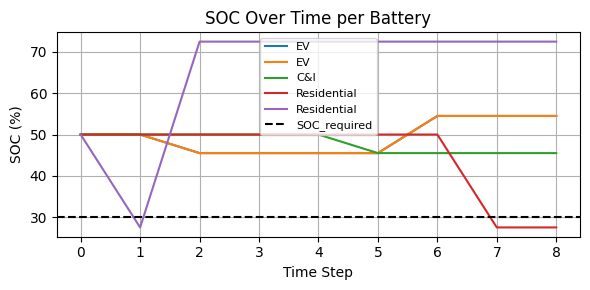

In [39]:
At = 1 ### Trading interval corresponds to one hour

Emax = list(df_expanded['Capacity(kWh)'])

battery_names = list(df_expanded['Type'])

arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]
d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge


# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge #### It's a plus because result_discharge is already negative

energy_array = balance_charge_discharge

# Initial SOC for each battery
SOC_initial = np.ones(energy_array.shape[0])  # shape = (5,)
SOC_initial = np.array(list(df_expanded['E_initial(kWh)'].astype(int)))/Emax  # shape = (5,)

# Transpose energy_array to shape (time, battery)
energy_array = energy_array.T  # shape becomes (8, 5)

# Initialize SOC array (time+1 steps x batteries)
SOC = np.zeros((energy_array.shape[0] + 1, energy_array.shape[1]))
SOC[0] = SOC_initial

# Compute SOC over time
for t in range(energy_array.shape[0]):
    SOC[t + 1] = SOC[t] + energy_array[t] / Emax
    SOC[t + 1] = np.clip(SOC[t + 1], 0, 1)  # Keep within [0, 1]

# Plot
plt.figure(figsize=(6, 3))
for i, name in enumerate(battery_names):
    plt.plot(SOC[:, i] * 100, label=name)

# Add SOC_required line at 30%
plt.axhline(req_final_energy_perc, linestyle='--', color='black', label='SOC_required')
plt.xlabel("Time Step")
plt.ylabel("SOC (%)")
plt.title("SOC Over Time per Battery")
plt.grid(True)
plt.legend(fontsize=8)  # Smaller legend font
plt.tight_layout()
plt.show()

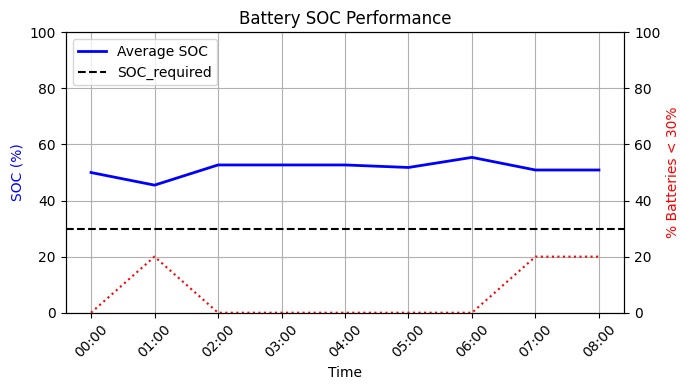

In [68]:
At = 1  # Trading interval corresponds to one hour

Emax = list(df_expanded['Capacity(kWh)'])
battery_names = list(df_expanded['Type'])

arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]
d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge

# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge  # It's a plus because result_discharge is already negative

energy_array = balance_charge_discharge

# Initial SOC for each battery
SOC_initial = np.ones(energy_array.shape[0])  # shape = (5,)
SOC_initial = np.array(list(df_expanded['E_initial(kWh)'].astype(int)))/Emax  # shape = (5,)

# Transpose energy_array to shape (time, battery)
energy_array = energy_array.T  # shape becomes (8, 5)

# Initialize SOC array (time+1 steps x batteries)
SOC = np.zeros((energy_array.shape[0] + 1, energy_array.shape[1]))
SOC[0] = SOC_initial

# Compute SOC over time
for t in range(energy_array.shape[0]):
    SOC[t + 1] = SOC[t] + energy_array[t] / Emax
    SOC[t + 1] = np.clip(SOC[t + 1], 0, 1)  # Keep within [0, 1]

# Create time labels
time_labels = [f"{i:02d}:00" for i in range(len(SOC))]

# Calculate average SOC across all batteries
avg_SOC = np.mean(SOC, axis=1) * 100

# Calculate percentage of batteries below 30% for each time step
below_threshold = np.sum(SOC < (req_final_energy_perc/100), axis=1)
percentage_below = (below_threshold / SOC.shape[1]) * 100

# Create plot with two y-axes
fig, ax1 = plt.subplots(figsize=(7, 4))

# Plot average SOC on primary axis
ax1.plot(avg_SOC, label='Average SOC', color='blue', linewidth=2)
ax1.axhline(req_final_energy_perc, linestyle='--', color='black', label='SOC_required')

# Set primary y-axis properties
ax1.set_xlabel("Time")
ax1.set_ylabel("SOC (%)", color='blue')
ax1.set_ylim(0, 100)
ax1.set_xticks(range(len(time_labels)))
ax1.set_xticklabels(time_labels, rotation=45)
ax1.grid(True)
ax1.legend(loc='upper left')

# Create secondary y-axis for percentage below threshold
ax2 = ax1.twinx()
ax2.plot(percentage_below, label='% Below Threshold', color='red', linestyle=':')
ax2.set_ylabel("% Batteries < 30%", color='red')
ax2.set_ylim(0, 100)

# Add title and adjust layout
plt.title("Battery SOC Performance")
fig.tight_layout()
plt.show()

In [41]:
df_expanded

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,1,200,20,10,90,90,100,60
1,EV,1,200,20,10,90,90,100,60
2,C&I,1,2000,200,100,90,90,1000,600
3,Residential,1,20,10,5,90,90,10,6
4,Residential,1,20,10,5,90,90,10,6


#### Profit and Loss evolution (PnL)

In [42]:
df

,Time Period,Buy Price ($/kWh),Sell Price ($/kWh),Forecasted Load (kW)
0,1,0.09,0.08,7608.0
1,2,0.12,0.09,8050.0
2,3,0.11,0.06,7864.0
3,4,0.10,0.10,7582.0
4,5,0.09,0.09,8224.0
5,6,0.09,0.07,7279.0
6,7,0.08,0.07,7584.0
7,8,0.11,0.07,7733.0


In [44]:
prices_buy = np.array(list(df['Buy Price ($/kWh)']))

# Step 1: sum energy column-wise
total_energy_per_time_charge = At * result_charge.sum(axis=0)  # shape = (8,)

# Step 2: multiply element-wise by prices
weighted_energy_value_charge = total_energy_per_time_charge * prices_buy  # shape = (8,)

# Total revenue or cost
total_value_cost = weighted_energy_value_charge.sum()

# Output
print("Energy charged per timestamp (kWh):", total_energy_per_time_charge)
print("Price-weighted energy charged:", weighted_energy_value_charge)
print("Total cost: $", total_value_cost)


prices_sell = np.array(list(df['Sell Price ($/kWh)']))

# Step 1: sum energy column-wise
total_energy_per_time_discharge = At * (-1)*result_discharge.sum(axis=0)  # shape = (8,)

# Step 2: multiply element-wise by prices
weighted_energy_value_discharge = total_energy_per_time_discharge * prices_sell  # shape = (8,)

# Total revenue or cost
total_value_revenue = weighted_energy_value_discharge.sum()

# Output
print("Energy discharged per timestamp (kWh):", total_energy_per_time_discharge)
print("Price-weighted energy discharged:", weighted_energy_value_discharge)
print("Total revenue: $", total_value_revenue)


############# Balance Energy Exchange = (Energy discharged per timestamp (kWh)) - (Energy charged per timestamp (kWh))

BEE = total_energy_per_time_discharge - total_energy_per_time_charge
PnL = weighted_energy_value_discharge - weighted_energy_value_charge

df['Balance_discharged_charged(kWh)'] = BEE
df['PnL($/kWh)'] = PnL

Energy charged per timestamp (kWh): [ 0.  9.  0.  0.  0. 36.  0.  0.]
Price-weighted energy charged: [0.   1.08 0.   0.   0.   3.24 0.   0.  ]
Total cost: $ 4.32
Energy discharged per timestamp (kWh): [ 4.5 18.  -0.  -0.  90.  -0.   4.5 -0. ]
Price-weighted energy discharged: [ 0.36   1.62  -0.    -0.     8.1   -0.     0.315 -0.   ]
Total revenue: $ 10.395


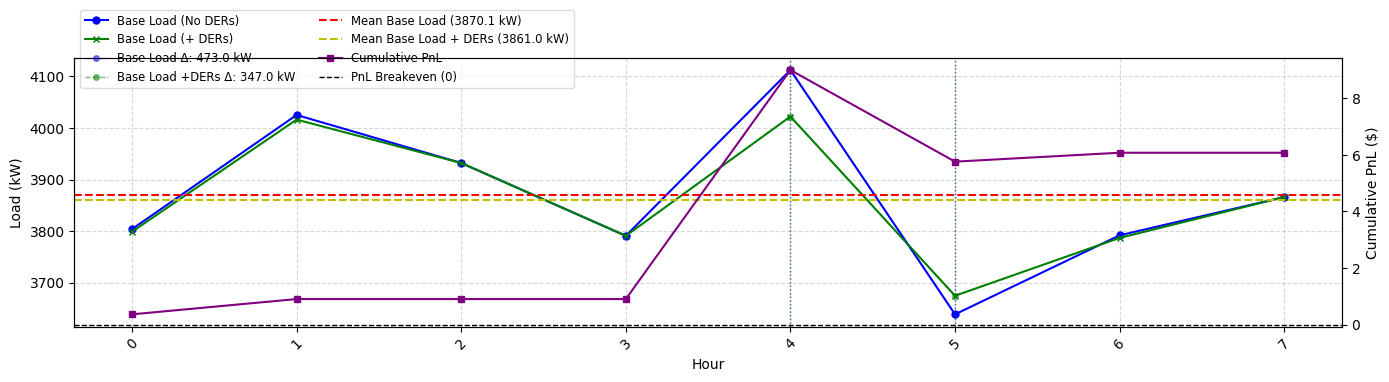

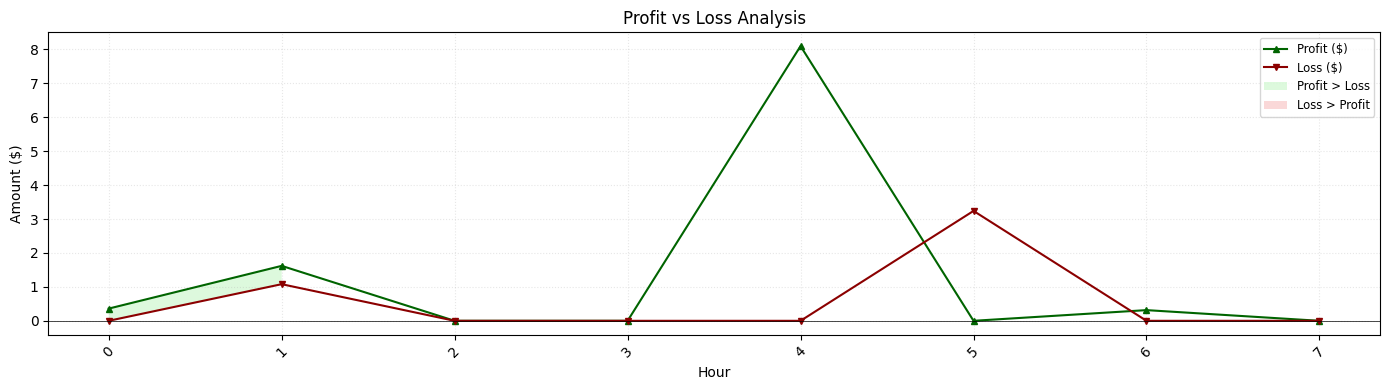

In [67]:
# Prepare the dataframe
df_k1 = df.copy()
df_k1['Projected_Load_kW_1'] = (df_k1['Forecasted Load (kW)'] / 2).astype(int)
df_k1['Grid_to_DERs'] = total_energy_per_time_charge  # Charge
df_k1['DERs_to_Grid'] = total_energy_per_time_discharge  # Discharge
df_k1['Demand_plus_DERs'] = (df_k1['Projected_Load_kW_1'] + df_k1['Grid_to_DERs'] - df_k1['DERs_to_Grid']).astype(int)
df_k1['PnL_cum'] = np.cumsum(df_k1['PnL($/kWh)'])
df_k1['Profit ($)'] = weighted_energy_value_discharge
df_k1['Loss ($)'] = weighted_energy_value_charge

# Extract the data
hours = df_k1.index
demand = df_k1['Projected_Load_kW_1']
demand_plus_ders = df_k1['Demand_plus_DERs']
mean_demand = demand.mean()
mean_demand_plus_ders = demand_plus_ders.mean()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(14, 4))  # Increased height to accommodate legend

# Plot Demand and Demand + DERs on primary axis
ax1.plot(hours, demand, label='Base Load (No DERs)', marker='o', color='blue', markersize=5)
ax1.plot(hours, demand_plus_ders, label='Base Load (+ DERs)', marker='x', color='green', markersize=5)

# --- NEW PEAK/TRACK ANALYSIS ---
# Find peaks and troughs for Demand
demand_max_idx = demand.idxmax()
demand_min_idx = demand.idxmin()
demand_max_val = demand.max()
demand_min_val = demand.min()

# Find peaks and troughs for Demand + DERs
ders_max_idx = demand_plus_ders.idxmax()
ders_min_idx = demand_plus_ders.idxmin()
ders_max_val = demand_plus_ders.max()
ders_min_val = demand_plus_ders.min()

# Add vertical lines and difference indicators for Demand
ax1.axvline(x=demand_max_idx, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=demand_min_idx, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax1.plot([demand_max_idx, demand_min_idx], [demand_max_val, demand_min_val],
        'bo--', alpha=0.5, linewidth=1, markersize=4,
        label=f'Base Load Δ: {demand_max_val-demand_min_val:.1f} kW')

# Add vertical lines and difference indicators for Demand + DERs
ax1.axvline(x=ders_max_idx, color='green', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=ders_min_idx, color='green', linestyle=':', alpha=0.5, linewidth=1)
ax1.plot([ders_max_idx, ders_min_idx], [ders_max_val, ders_min_val],
        'go--', alpha=0.5, linewidth=1, markersize=4,
        label=f'Base Load +DERs Δ: {ders_max_val-ders_min_val:.1f} kW')
# --- END NEW CODE ---

# Add mean reference lines
ax1.axhline(y=mean_demand, color='r', linestyle='--', label=f'Mean Base Load ({mean_demand:.1f} kW)')
ax1.axhline(y=mean_demand_plus_ders, color='y', linestyle='--', label=f'Mean Base Load + DERs ({mean_demand_plus_ders:.1f} kW)')

# Customize primary axis
ax1.set_xlabel('Hour')
ax1.set_ylabel('Load (kW)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Create secondary axis
ax2 = ax1.twinx()
ax2.plot(hours, df_k1['PnL_cum'], label='Cumulative PnL', color='purple', linestyle='-', marker='s', markersize=5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, label='PnL Breakeven (0)')
ax2.set_ylabel('Cumulative PnL ($)')

# Combine and format legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
          loc='upper left',
          fontsize='small',
          framealpha=0.7,
          ncol=2,
          bbox_to_anchor=(0, 1.2))  # Adjusted for extra items

plt.tight_layout()
plt.show()

#############################################
# SECOND PLOT: Profit/Loss with filled areas #
#############################################

fig, ax = plt.subplots(figsize=(14, 4))

# Plot Profit/Loss lines
ax.plot(hours, df_k1['Profit ($)'], label='Profit ($)', color='darkgreen', linewidth=1.5, marker='^', markersize=4)
ax.plot(hours, df_k1['Loss ($)'], label='Loss ($)', color='darkred', linewidth=1.5, marker='v', markersize=4)

# Fill between the lines
ax.fill_between(hours,
               df_k1['Profit ($)'],
               df_k1['Loss ($)'],
               where=(df_k1['Profit ($)'] > df_k1['Loss ($)']),
               facecolor='lightgreen',
               alpha=0.3,
               label='Profit > Loss')

ax.fill_between(hours,
               df_k1['Profit ($)'],
               df_k1['Loss ($)'],
               where=(df_k1['Loss ($)'] > df_k1['Profit ($)']),
               facecolor='lightcoral',
               alpha=0.3,
               label='Loss > Profit')

# Add zero line
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Formatting
ax.set_title('Profit vs Loss Analysis')
ax.set_xlabel('Hour')
ax.set_ylabel('Amount ($)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, which='both', linestyle=':', alpha=0.3)
ax.legend(fontsize='small', framealpha=0.8)

plt.tight_layout()
plt.show()

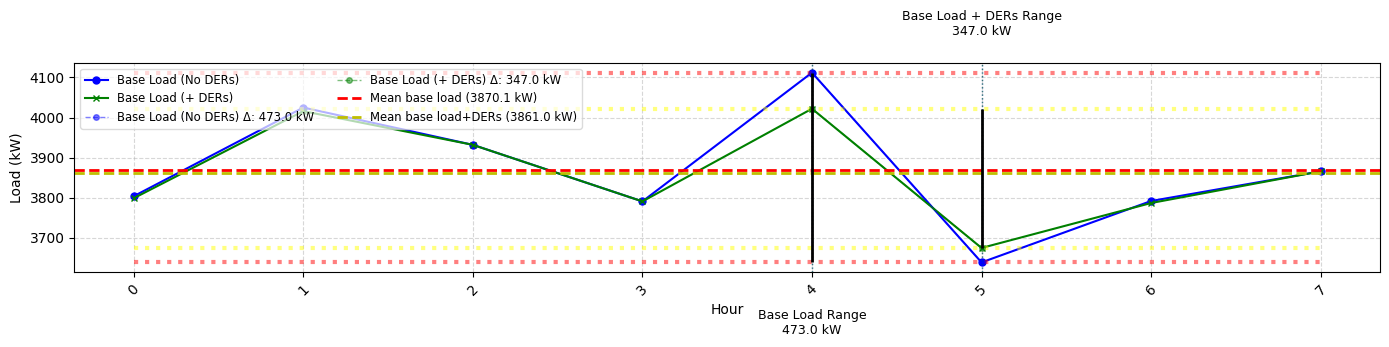

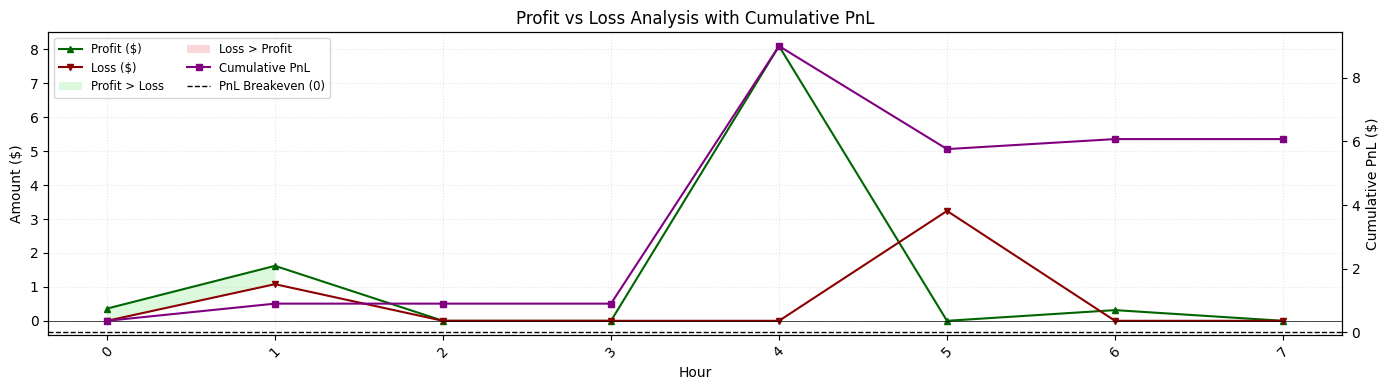

In [58]:
# Prepare the dataframe
df_k1 = df.copy()
df_k1['Projected_Load_kW_1'] = (df_k1['Forecasted Load (kW)'] / 2).astype(int)
df_k1['Grid_to_DERs'] = total_energy_per_time_charge  # Charge
df_k1['DERs_to_Grid'] = total_energy_per_time_discharge  # Discharge
df_k1['Demand_plus_DERs'] = (df_k1['Projected_Load_kW_1'] + df_k1['Grid_to_DERs'] - df_k1['DERs_to_Grid']).astype(int)
df_k1['PnL_cum'] = np.cumsum(df_k1['PnL($/kWh)'])
df_k1['Profit ($)'] = weighted_energy_value_discharge
df_k1['Loss ($)'] = weighted_energy_value_charge

# Extract the data
hours = df_k1.index
demand = df_k1['Projected_Load_kW_1']
demand_plus_ders = df_k1['Demand_plus_DERs']
mean_demand = demand.mean()
mean_demand_plus_ders = demand_plus_ders.mean()

#############################################
# FIRST PLOT: Demand vs Demand+DERs with range lines
#############################################
fig, ax1 = plt.subplots(figsize=(14, 4))  # Increased height for better visibility

# Plot Demand and Demand + DERs
ax1.plot(hours, demand, label='Base Load (No DERs)', marker='o', color='blue', markersize=5)
ax1.plot(hours, demand_plus_ders, label='Base Load (+ DERs)', marker='x', color='green', markersize=5)

# Find peaks and troughs for Demand
demand_max_idx = demand.idxmax()
demand_min_idx = demand.idxmin()
demand_max_val = demand.max()
demand_min_val = demand.min()

# Find peaks and troughs for Demand + DERs
ders_max_idx = demand_plus_ders.idxmax()
ders_min_idx = demand_plus_ders.idxmin()
ders_max_val = demand_plus_ders.max()
ders_min_val = demand_plus_ders.min()

# Add vertical lines for Demand
ax1.axvline(x=demand_max_idx, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=demand_min_idx, color='blue', linestyle=':', alpha=0.5, linewidth=1)

# Add vertical lines for Demand + DERs
ax1.axvline(x=ders_max_idx, color='green', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=ders_min_idx, color='green', linestyle=':', alpha=0.5, linewidth=1)

# Add FOUR horizontal dotted lines showing the ranges
# For Demand (red lines)
ax1.hlines(y=demand_max_val, xmin=hours[0], xmax=hours[-1], 
           colors='red', linestyles='dotted', alpha=0.5, linewidth=3)
ax1.hlines(y=demand_min_val, xmin=hours[0], xmax=hours[-1], 
           colors='red', linestyles='dotted', alpha=0.5, linewidth=3)

# For Demand+DERs (yellow lines)
ax1.hlines(y=ders_max_val, xmin=hours[0], xmax=hours[-1], 
           colors='yellow', linestyles='dotted', alpha=0.5, linewidth=3)
ax1.hlines(y=ders_min_val, xmin=hours[0], xmax=hours[-1], 
           colors='yellow', linestyles='dotted', alpha=0.5, linewidth=3)

# Add connecting lines with labels showing the delta values
ax1.plot([demand_max_idx, demand_min_idx], [demand_max_val, demand_min_val],
        'bo--', alpha=0.5, linewidth=1, markersize=4,
        label=f'Base Load (No DERs) Δ: {demand_max_val-demand_min_val:.1f} kW')

ax1.plot([ders_max_idx, ders_min_idx], [ders_max_val, ders_min_val],
        'go--', alpha=0.5, linewidth=1, markersize=4,
        label=f'Base Load (+ DERs) Δ: {ders_max_val-ders_min_val:.1f} kW')

# Add mean reference lines
ax1.axhline(y=mean_demand, color='r', linestyle='--', linewidth=2, label=f'Mean base load ({mean_demand:.1f} kW)')
ax1.axhline(y=mean_demand_plus_ders, color='y', linestyle='--', linewidth=2, label=f'Mean base load+DERs ({mean_demand_plus_ders:.1f} kW)')

# Add vertical lines between the highest and lowest lines
if hasattr(hours, 'hour'):  # Check if it's datetime-like
    mid_point = hours[len(hours)//2]
    offset_point = hours[len(hours)//2 + 1] if len(hours) > 1 else mid_point
else:
    mid_point = len(hours)//2
    offset_point = len(hours)//2 + 1 if len(hours) > 1 else mid_point

# Vertical line for Demand range (red lines)
demand_range_mid = (demand_min_val + demand_max_val) / 2
ax1.vlines(x=mid_point, ymin=demand_min_val, ymax=demand_max_val, 
           colors='black', linestyles='solid', linewidth=2)
ax1.text(
    mid_point, demand_range_mid - (0.1 * demand_range_mid),  # Offset downward
    f'Base Load Range\n{demand_max_val-demand_min_val:.1f} kW', 
    ha='center', va='center', 
    backgroundcolor='white',
    fontsize=9
)

# Vertical line for Demand+DERs range (yellow lines)
ders_range_mid = (ders_min_val + ders_max_val) / 2
ax1.vlines(x=offset_point, ymin=ders_min_val, ymax=ders_max_val, 
           colors='black', linestyles='solid', linewidth=2)
ax1.text(
    offset_point, ders_range_mid + (0.1 * ders_range_mid),  # Offset upward
    f'Base Load + DERs Range\n{ders_max_val-ders_min_val:.1f} kW', 
    ha='center', va='center', 
    backgroundcolor='white',
    fontsize=9
)

# Customize primary axis
ax1.set_xlabel('Hour')
ax1.set_ylabel('Load (kW)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', fontsize='small', framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()

#############################################
# SECOND PLOT: Profit/Loss with Cumulative PnL
#############################################
fig, ax1 = plt.subplots(figsize=(14, 4))

# Plot Profit/Loss lines on primary axis
ax1.plot(hours, df_k1['Profit ($)'], label='Profit ($)', color='darkgreen', linewidth=1.5, marker='^', markersize=4)
ax1.plot(hours, df_k1['Loss ($)'], label='Loss ($)', color='darkred', linewidth=1.5, marker='v', markersize=4)

# Fill between the lines
ax1.fill_between(hours,
               df_k1['Profit ($)'],
               df_k1['Loss ($)'],
               where=(df_k1['Profit ($)'] > df_k1['Loss ($)']),
               facecolor='lightgreen',
               alpha=0.3,
               label='Profit > Loss')

ax1.fill_between(hours,
               df_k1['Profit ($)'],
               df_k1['Loss ($)'],
               where=(df_k1['Loss ($)'] > df_k1['Profit ($)']),
               facecolor='lightcoral',
               alpha=0.3,
               label='Loss > Profit')

# Add zero line
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Create secondary axis for Cumulative PnL
ax2 = ax1.twinx()
ax2.plot(hours, df_k1['PnL_cum'], label='Cumulative PnL', color='purple', linestyle='-', marker='s', markersize=5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, label='PnL Breakeven (0)')
ax2.set_ylabel('Cumulative PnL ($)')

# Formatting
ax1.set_title('Profit vs Loss Analysis with Cumulative PnL')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Amount ($)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, which='both', linestyle=':', alpha=0.3)

# Combine legends - using frameon instead of framecolor
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper left', 
           fontsize='small', 
           frameon=True,
           facecolor='white',
           framealpha=0.8,
           ncol=2)

plt.tight_layout()
plt.show()

In [53]:
df_k1

,Time Period,Buy Price ($/kWh),Sell Price ($/kWh),Forecasted Load (kW),Balance_discharged_charged(kWh),PnL($/kWh),Projected_Load_kW_1,Grid_to_DERs,DERs_to_Grid,Demand_plus_DERs,PnL_cum,Profit ($),Loss ($)
0,1,0.09,0.08,7608.0,4.5,0.360,3804,0.0,4.5,3799,0.360,0.360,0.00
1,2,0.12,0.09,8050.0,9.0,0.540,4025,9.0,18.0,4016,0.900,1.620,1.08
2,3,0.11,0.06,7864.0,-0.0,-0.000,3932,0.0,-0.0,3932,0.900,-0.000,0.00
3,4,0.10,0.10,7582.0,-0.0,-0.000,3791,0.0,-0.0,3791,0.900,-0.000,0.00
4,5,0.09,0.09,8224.0,90.0,8.100,4112,0.0,90.0,4022,9.000,8.100,0.00
5,6,0.09,0.07,7279.0,-36.0,-3.240,3639,36.0,-0.0,3675,5.760,-0.000,3.24
6,7,0.08,0.07,7584.0,4.5,0.315,3792,0.0,4.5,3787,6.075,0.315,0.00
7,8,0.11,0.07,7733.0,-0.0,-0.000,3866,0.0,-0.0,3866,6.075,-0.000,0.00


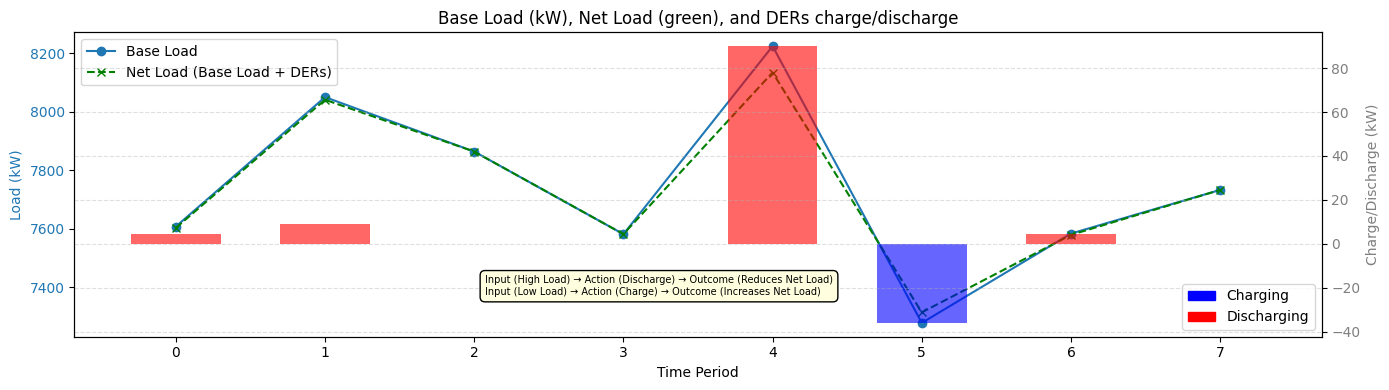

In [56]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Prepare bar colors
bar_colors = df_k1["Balance_discharged_charged(kWh)"].apply(
    lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray')
)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 4))

# Line: Projected Load (blue)
ax1.set_title("Base Load (kW), Net Load (green), and DERs charge/discharge")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Load (kW)", color='tab:blue')
ax1.plot(df_k1.index, df_k1["Forecasted Load (kW)"], label="Base Load", marker='o', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Line: Net Load (green) = Projected Load + Balance
ax1.plot(
    df_k1.index,
    df_k1["Forecasted Load (kW)"] - df_k1["Balance_discharged_charged(kWh)"],
    label="Net Load (Base Load + DERs)",
    linestyle='--',
    color='green',
    marker='x'
)
ax1.legend(loc="upper left")

# Bars: Energy Balance (red/blue)
ax2 = ax1.twinx()
ax2.set_ylabel("Charge/Discharge (kW)", color='tab:gray')
ax2.bar(
    df_k1.index,
    df_k1["Balance_discharged_charged(kWh)"],
    color=bar_colors,
    alpha=0.6,
    width=0.6
)
ax2.tick_params(axis='y', labelcolor='tab:gray')

# Custom legend for bar colors
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', label='Charging'),
    Patch(facecolor='red', edgecolor='red', label='Discharging')
]
ax2.legend(handles=legend_elements, loc='lower right')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Add explanation box
textstr = (
    "Input (High Load) → Action (Discharge) → Outcome (Reduces Net Load)\n"
    "Input (Low Load) → Action (Charge) → Outcome (Increases Net Load)"
)
plt.gcf().text(
    0.35, 0.25, textstr,
    fontsize=7,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.show()

In [60]:
df_k1

,Time Period,Buy Price ($/kWh),Sell Price ($/kWh),Forecasted Load (kW),Balance_discharged_charged(kWh),PnL($/kWh),Projected_Load_kW_1,Grid_to_DERs,DERs_to_Grid,Demand_plus_DERs,PnL_cum,Profit ($),Loss ($)
0,1,0.09,0.08,7608.0,4.5,0.360,3804,0.0,4.5,3799,0.360,0.360,0.00
1,2,0.12,0.09,8050.0,9.0,0.540,4025,9.0,18.0,4016,0.900,1.620,1.08
2,3,0.11,0.06,7864.0,-0.0,-0.000,3932,0.0,-0.0,3932,0.900,-0.000,0.00
3,4,0.10,0.10,7582.0,-0.0,-0.000,3791,0.0,-0.0,3791,0.900,-0.000,0.00
4,5,0.09,0.09,8224.0,90.0,8.100,4112,0.0,90.0,4022,9.000,8.100,0.00
5,6,0.09,0.07,7279.0,-36.0,-3.240,3639,36.0,-0.0,3675,5.760,-0.000,3.24
6,7,0.08,0.07,7584.0,4.5,0.315,3792,0.0,4.5,3787,6.075,0.315,0.00
7,8,0.11,0.07,7733.0,-0.0,-0.000,3866,0.0,-0.0,3866,6.075,-0.000,0.00


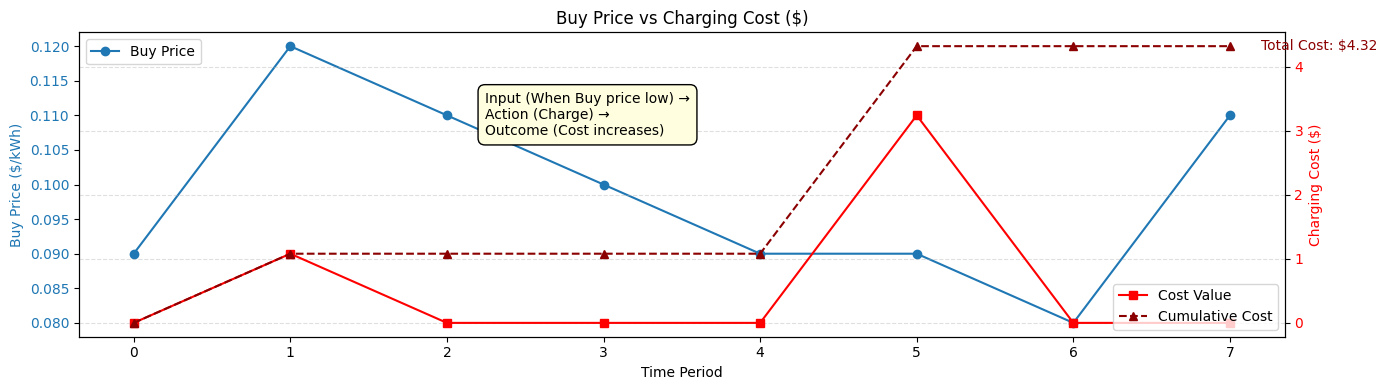

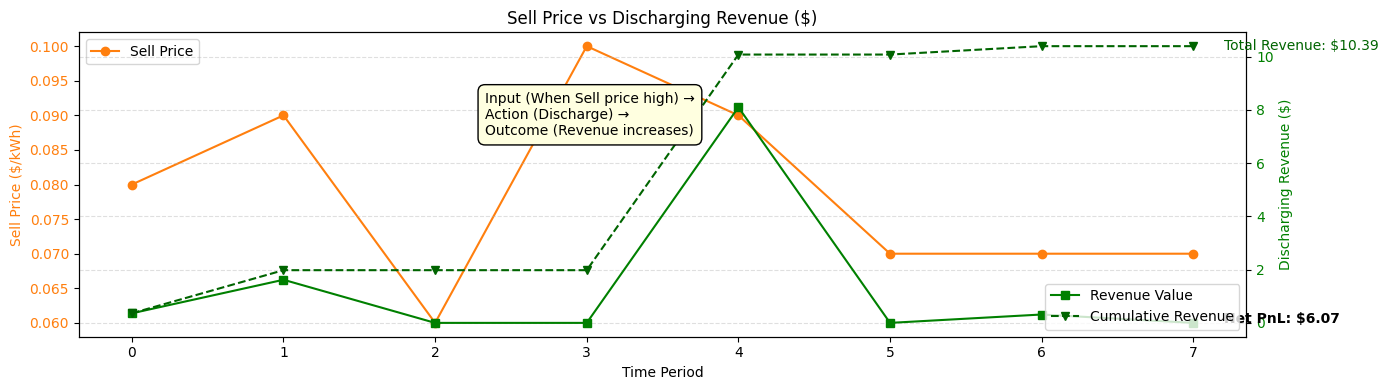

In [61]:
# Ensure numeric time axis
time_periods = np.arange(len(df_k1))  # [0, 1, 2, ..., N-1]

# --- Plot 1: Buy Price vs Charging Cost ---
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.set_title("Buy Price vs Charging Cost ($)")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Buy Price ($/kWh)", color='tab:blue')
ax1.plot(time_periods, df_k1["Buy Price ($/kWh)"], marker='o', label='Buy Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Right y-axis for cost and cumulative cost
ax2 = ax1.twinx()
ax2.set_ylabel("Charging Cost ($)", color='red')
ax2.plot(time_periods, weighted_energy_value_charge, marker='s', label='Cost Value', color='red')
ax2.plot(time_periods, np.cumsum(weighted_energy_value_charge), marker='^', linestyle='--', label='Cumulative Cost', color='darkred')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='lower right')

# Annotate final cumulative cost
final_cost = np.cumsum(weighted_energy_value_charge)[-1]
ax2.text(
    time_periods[-1] + 0.2,
    final_cost,
    f"Total Cost: ${final_cost:.2f}",
    color='darkred',
    fontsize=10,
    va='center'
)

# Explanation box
textstr = ("Input (When Buy price low) →\n" 
"Action (Charge) →\n"
"Outcome (Cost increases)")

plt.gcf().text(
    0.35, 0.65, textstr,
    fontsize=10,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# --- Plot 2: Sell Price vs Discharging Revenue ---
fig, ax3 = plt.subplots(figsize=(14, 4))
ax3.set_title("Sell Price vs Discharging Revenue ($)")
ax3.set_xlabel("Time Period")
ax3.set_ylabel("Sell Price ($/kWh)", color='tab:orange')
ax3.plot(time_periods, df_k1["Sell Price ($/kWh)"], marker='o', label='Sell Price', color='tab:orange')
ax3.tick_params(axis='y', labelcolor='tab:orange')
ax3.legend(loc='upper left')

# Right y-axis for revenue and cumulative revenue
ax4 = ax3.twinx()
ax4.set_ylabel("Discharging Revenue ($)", color='green')
ax4.plot(time_periods, weighted_energy_value_discharge, marker='s', label='Revenue Value', color='green')
ax4.plot(time_periods, np.cumsum(weighted_energy_value_discharge), marker='v', linestyle='--', label='Cumulative Revenue', color='darkgreen')
ax4.tick_params(axis='y', labelcolor='green')
ax4.legend(loc='lower right')

# Annotate final cumulative revenue
final_revenue = np.cumsum(weighted_energy_value_discharge)[-1]
ax4.text(
    time_periods[-1] + 0.2,
    final_revenue,
    f"Total Revenue: ${final_revenue:.2f}",
    color='darkgreen',
    fontsize=10,
    va='center'
)

# Calculate and annotate Net PnL
net_pnl = final_revenue - final_cost
ax4.text(
    time_periods[-1] + 0.2,
    final_revenue - 10,  # adjust as needed
    f"Net PnL: ${net_pnl:.2f}",
    color='black',
    fontsize=10,
    fontweight='bold',
    va='top'
)

# Explanation box
# Explanation box
textstr = ("Input (When Sell price high) →\n" 
"Action (Discharge) →\n"
"Outcome (Revenue increases)")

plt.gcf().text(
    0.35, 0.65, textstr,
    fontsize=10,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [62]:
print("PnL: $", PnL.sum())
print("BEE: kWh", BEE.sum())

PnL: $ 6.074999999999999
BEE: kWh 72.0
